In [1]:
import nd2
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from scipy.ndimage import gaussian_filter

sigma = (0.0, 1.0, 1.0)

p_dir = Path('/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp001')

p_file = p_dir / 'exp001.nd2'
file = nd2.imread(p_file, dask = True)

images = file[:, 1, :, :]


images_blur = gaussian_filter(images, sigma)

In [2]:
def comp8bit(img_u16):
    # 1. 最小値と最大値を計算（ここが一番コストが高い）
    p_min, p_max = img_u16.min(), img_u16.max()
    
    # 2. 0-255に収めるための係数を計算
    diff = p_max - p_min
    if diff == 0:
        return np.zeros_like(img_u16, dtype=np.uint8)
    
    scale = 255.0 / diff
    
    # 3. 演算を一つにまとめて、最後にキャスト
    # (x - min) * scale を一気に行う
    return ((img_u16 - p_min) * scale).astype(np.uint8)
images_8bit = comp8bit(images_blur)

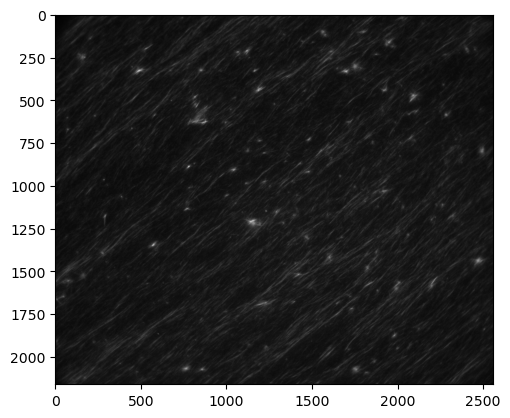

In [3]:
plt.imshow(images_8bit[0], cmap = 'gray')

In [9]:
prev = images_8bit[0]
next = images_8bit[1]

flows = cv2.calcOpticalFlowFarneback(prev, next, 0, pyr_scale = 0.5, levels = 3, winsize = 7, iterations = 3, poly_n = 5, poly_sigma = 1.1, flags = cv2.OPTFLOW_FARNEBACK_GAUSSIAN)

In [13]:
magnitude = np.sqrt(flows[..., 0]**2 + flows[..., 1]**2)
# nd2のメタデータから取得（例）
pixel_size_um = 0.11  # 1ピクセルが何マイクロメートルか
frame_interval_sec = 4  # 1フレームが何秒か

# 物理速度 (um/s) への変換
# (pixels/frame) * (um/pixel) / (sec/frame) = um/s
velocity_um_s = magnitude * pixel_size_um / frame_interval_sec

print(np.mean(velocity_um_s), "um/s")

0.055796407 um/s


In [23]:
# 速度が極端に高い（物理的にあり得ない）値をカット
v_max_threshold = 1.0  # 例: 100 um/s 以上はノイズとみなす
v_min_threshold = 0.1
velocity_um_s_filtered = np.where((velocity_um_s < v_max_threshold) & (v_min_threshold < velocity_um_s), velocity_um_s, np.nan)

print(np.nanmean(velocity_um_s_filtered), "um/s")

0.20953774 um/s


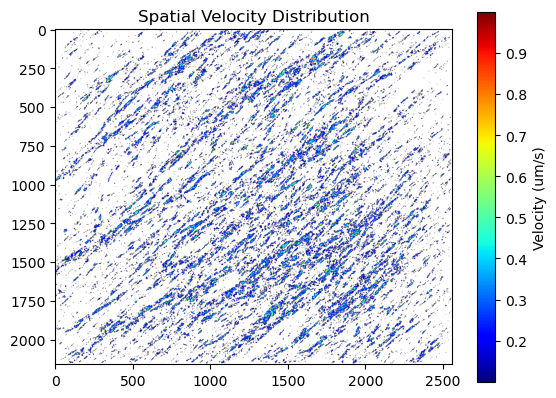

In [24]:
# 特定のフレームの速度マップを表示
plt.imshow(velocity_um_s_filtered, cmap='jet')
plt.colorbar(label='Velocity (um/s)')
plt.title("Spatial Velocity Distribution")
plt.show()

(array([5.03416e+05, 2.17576e+05, 1.06953e+05, 4.96610e+04, 1.92810e+04,
        7.25300e+03, 2.53000e+03, 8.36000e+02, 2.66000e+02, 1.08000e+02]),
 array([0.10000011, 0.18995571, 0.27991134, 0.36986694, 0.45982257,
        0.54977816, 0.63973373, 0.72968936, 0.81964499, 0.90960062,
        0.99955624]),
 <BarContainer object of 10 artists>)

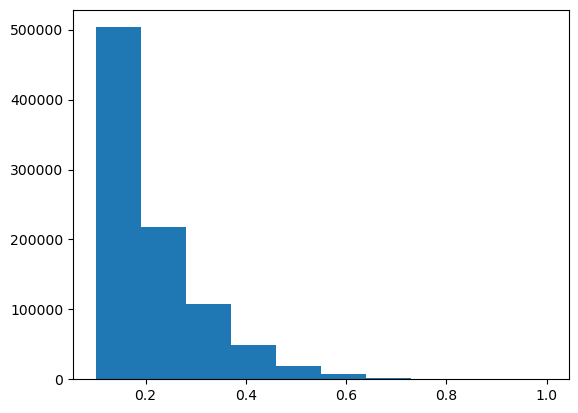

In [25]:
plt.hist(velocity_um_s_filtered.reshape(-1))

In [ ]:
import cv2

# 移動量 18px に最適化したパラメータ
params = dict(
    pyr_scale=0.5, 
    levels=5,          # 階層を増やす（18pxなら5層以上必要）
    winsize=41,        # 移動量よりも大きいサイズを確保。2倍程度が安定
    iterations=3, 
    poly_n=7,          # 大きな動きにはより滑らかな近似（7）が有効
    poly_sigma=1.5, 
    flags=cv2.OPTFLOW_USE_INITIAL_FLOW # 前フレームの慣性を利用
)